# SENSEI™ — ניתוח זוויות שיווקיות ב-Meta Ads

נוטבוק זה טוען את הנתונים המעובדים (`data/processed_by_angle.csv`), מחשב rollup לפי זווית שיווקית, ומייצר את שני הגרפים המרכזיים של הפרויקט — אותו ניתוח בדיוק כמו ב-`README.md` וב-SQL, הפעם בפייתון.

**קלט:** `data/processed_by_angle.csv` (16 מודעות, 7 זוויות שיווקיות, נבנה על ידי `scripts/build_report.py`)


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

plt.rcParams['font.family'] = 'DejaVu Sans'

df = pd.read_csv('../data/processed_by_angle.csv')
df.shape


(16, 22)

## Rollup לפי זווית שיווקית

סדר הזוויות תואם ל-README. עבור כל זווית: נפח (חשיפות/קליקים), CTR, שיעור הוספה-לעגלה מקליקים, שיעור מעבר-לתשלום מקליקים, ומספר הרכישות.


In [2]:
ANGLE_ORDER = [
    'הוק "זה אתם?"', 'הוק "לכל האמהות"', 'פנייה ישירה לאמהות (קליקבייט)',
    'ניקיון ותחזוקה', 'בריאות / רעלים / מיקרופלסטיק', 'FOMO ונראות', 'חסכון לטווח ארוך',
]

agg = df.groupby('angle').agg(
    ads=('ad_id', 'count'), impressions=('impressions', 'sum'), clicks=('clicks', 'sum'),
    add_to_cart=('add_to_cart', 'sum'), checkout=('initiate_checkout', 'sum'), purchases=('purchases', 'sum')
).reindex(ANGLE_ORDER)

agg['ctr_pct'] = (agg['clicks'] / agg['impressions'] * 100).round(2)
agg['atc_rate_pct'] = (agg['add_to_cart'] / agg['clicks'] * 100).round(2)
agg['checkout_rate_pct'] = (agg['checkout'] / agg['clicks'] * 100).round(2)

print(agg[['ads', 'impressions', 'clicks', 'ctr_pct', 'atc_rate_pct', 'checkout_rate_pct', 'purchases']])


                               ads  impressions  clicks  ctr_pct  atc_rate_pct  checkout_rate_pct  purchases
angle
הוק "זה אתם?"                    3         4326    61.0     1.41         11.48               3.28        1.0
הוק "לכל האמהות"                 2         1429    22.0     1.54         27.27               4.55        1.0
פנייה ישירה לאמהות (קליקבייט)    1         1994   124.0     6.22          2.42               1.61        1.0
ניקיון ותחזוקה                   3        13767   392.0     2.85          3.83               2.81        1.0
בריאות / רעלים / מיקרופלסטיק     5        13421   251.0     1.87          3.98               1.99        1.0
FOMO ונראות                      1          113     4.0     3.54          0.00               0.00        0.0
חסכון לטווח ארוך                 1          538     6.0     1.12          0.00              33.33        0.0

## גרף 1: CTR מול שיעור הוספה-לעגלה

**התובנה המרכזית של הפרויקט:** CTR גבוה לא אומר שהתנועה איכותית. הזווית עם ה-CTR הכי גבוה ("פנייה ישירה לאמהות", קליקבייט) דווקא ממירה הכי גרוע להוספה-לעגלה, בעוד ש"לכל האמהות" (אורגני, CTR נמוך) ממיר הכי טוב.


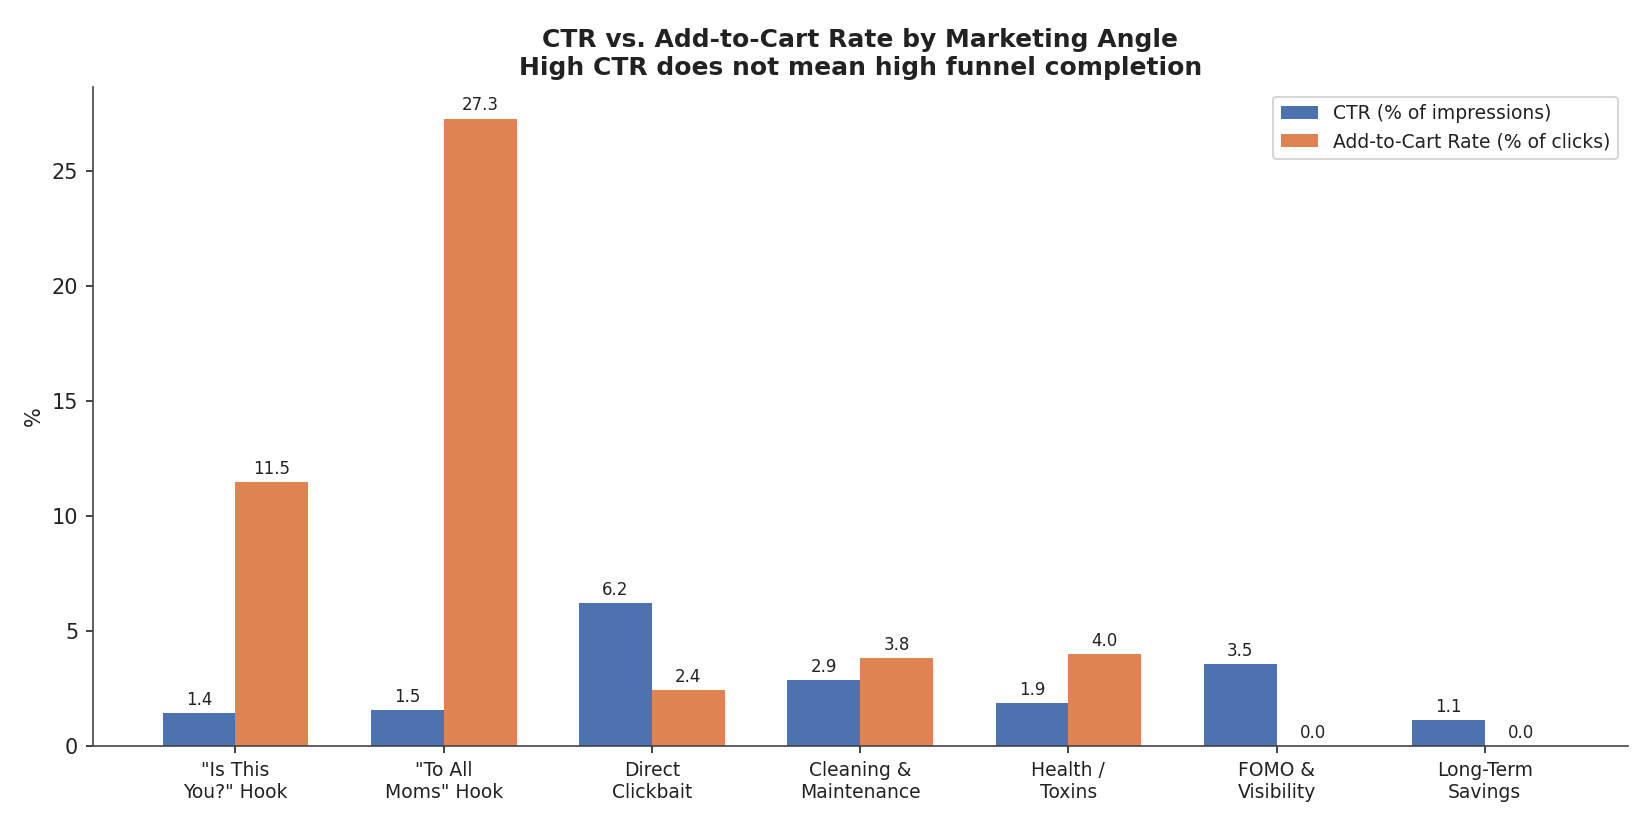

In [3]:
ANGLE_LABEL_EN = {
    'הוק "זה אתם?"': '"Is This\nYou?" Hook',
    'הוק "לכל האמהות"': '"To All\nMoms" Hook',
    'פנייה ישירה לאמהות (קליקבייט)': 'Direct\nClickbait',
    'ניקיון ותחזוקה': 'Cleaning &\nMaintenance',
    'בריאות / רעלים / מיקרופלסטיק': 'Health /\nToxins',
    'FOMO ונראות': 'FOMO &\nVisibility',
    'חסכון לטווח ארוך': 'Long-Term\nSavings',
}
# הערה: תוויות הצירים באנגלית בכוונה -- ל-matplotlib אין תמיכת RTL אמיתית,
# וטקסט עברי בתרשים (לא בתא markdown) היה מוצג הפוך.
labels = [ANGLE_LABEL_EN[a] for a in agg.index]

fig, ax = plt.subplots(figsize=(11, 5.5))
x = np.arange(len(labels))
width = 0.35
b1 = ax.bar(x - width/2, agg['ctr_pct'], width, label='CTR (% of impressions)', color='#4C72B0')
b2 = ax.bar(x + width/2, agg['atc_rate_pct'], width, label='Add-to-Cart Rate (% of clicks)', color='#DD8452')
ax.set_xticks(x)
ax.set_xticklabels(labels, fontsize=9)
ax.set_ylabel('%')
ax.set_title('CTR vs. Add-to-Cart Rate by Marketing Angle\nHigh CTR does not mean high funnel completion', fontsize=12, fontweight='bold')
ax.legend(fontsize=9)
ax.bar_label(b1, fmt='%.1f', fontsize=8, padding=2)
ax.bar_label(b2, fmt='%.1f', fontsize=8, padding=2)
ax.spines[['top', 'right']].set_visible(False)
fig.tight_layout()
fig.savefig('../charts/ctr_vs_atc_rate_by_angle.png', dpi=150, facecolor='white')
plt.show()


## גרף 2: נפח קליקים לפי זווית

ירוק = הזווית הזו הניבה לפחות רכישה אחת. אפור = לא. רואים כאן ש"ניקיון ותחזוקה" היא הזווית שהוכיחה את עצמה גם בנפח (392 קליקים) וגם ברכישה בפועל — לא רק בפיילוט קטן.


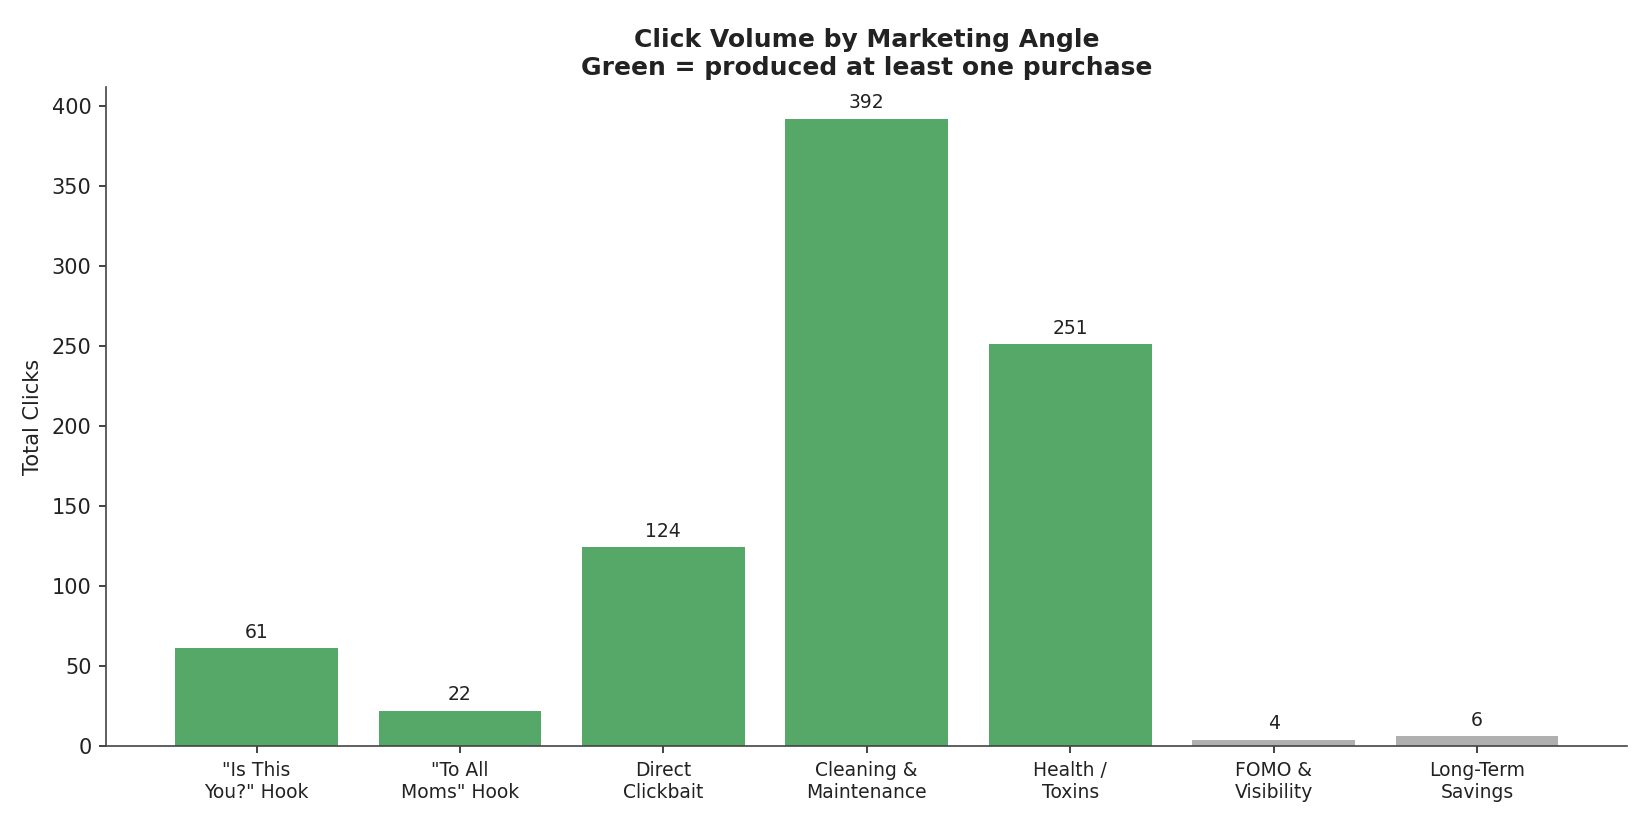

In [4]:
colors = ['#55A868' if p > 0 else '#B0B0B0' for p in agg['purchases']]

fig, ax = plt.subplots(figsize=(11, 5.5))
bars = ax.bar(labels, agg['clicks'], color=colors)
ax.set_ylabel('Total Clicks')
ax.set_title('Click Volume by Marketing Angle\nGreen = produced at least one purchase', fontsize=12, fontweight='bold')
ax.bar_label(bars, fmt='%.0f', fontsize=9, padding=3)
ax.spines[['top', 'right']].set_visible(False)
fig.tight_layout()
fig.savefig('../charts/clicks_by_angle.png', dpi=150, facecolor='white')
plt.show()


## תובנות עסקיות

1. **CTR גבוה הוא לא מדד להצלחה — הוא מדד לסקרנות.** "פנייה ישירה לאמהות" (קליקבייט) מייצרת CTR של 6.22%, פי 3-4 מרוב הזוויות, אבל רק 2.42% מהקליקים ממשיכים להוספה-לעגלה.
2. **"לכל האמהות" (אורגני) — יחס ההמרה הכי חזק.** 27.27% מהקליקים הופכים להוספה-לעגלה, פי 7-10 מרוב הזוויות האחרות, למרות נפח קטן (22 קליקים בלבד).
3. **"ניקיון ותחזוקה" — הזווית היחידה שהוכיחה את עצמה גם בהיקף וגם באיכות.** 392 קליקים, שיעור המשכיות יציב, ורכישה בפועל.
4. **"בריאות/רעלים/מיקרופלסטיק" — זווית עקבית עם פוטנציאל.** 5 מודעות, שיעור הוספה-לעגלה גבוה יחסית (3.98%), רק אחת הגיעה לרכישה — שווה עוד בדיקה.
5. **FOMO לא צריכה להיות זווית מרכזית בשלב הזה** — עדיף כאלמנט בתוך זוויות אחרות. חסכון לטווח ארוך עדיין שאלה פתוחה (מדגם זעום).

פירוט מלא, כולל טבלאות ברמת מודעה בודדת, נמצא ב-`README.md`.
